# 5. Model Evaluation — FashionMNIST MLP

 load tập test, load checkpoint đã train, tính Test Loss/Test Accuracy, phân tích theo lớp, vẽ Confusion Matrix, hiển thị `Actual vs Predicted` và các ảnh dự đoán sai.
 **không train lại mô hình**.


In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn


def find_repo_root(start_path: Path) -> Path:
    start_path = start_path.resolve()
    for current_path in [start_path, *start_path.parents]:
        if (current_path / "Practice_1").is_dir():
            return current_path
    raise FileNotFoundError("Không tìm thấy thư mục gốc chứa Practice_1.")


REPO_ROOT = find_repo_root(Path.cwd())
PRACTICE_DIR = REPO_ROOT / "Practice_1"
SRC_DIR = PRACTICE_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data import create_dataloaders
from model import NeuralNetwork

try:
    from data import CLASS_NAMES
except ImportError:
    CLASS_NAMES = [
        "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
        "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
    ]

DATA_DIR = REPO_ROOT / "data"
MODEL_DIR = PRACTICE_DIR / "models"
FIGURE_DIR = PRACTICE_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Repository root:", REPO_ROOT)
print("Device:", device)
print("Classes:", CLASS_NAMES)


Repository root: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2
Device: cpu
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 5.1 kiểm tra model  


In [8]:
print("DataLoader function:", create_dataloaders)
print("Model class:", NeuralNetwork)

test_model = NeuralNetwork().to(device)
print(test_model)

DataLoader function: <function create_dataloaders at 0x000002317C4327A0>
Model class: <class 'model.NeuralNetwork'>
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 5.2. Load test dataset


In [9]:
train_dataset, test_dataset, train_loader, test_loader = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=64,
)

images, labels = next(iter(test_loader))

print("Test samples:", len(test_dataset))
print("Test batches:", len(test_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

assert images.shape[1:] == (1, 28, 28)


Test samples: 10000
Test batches: 157
Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


## 5.3. Load model đã huấn luyện


In [10]:
MODEL_PATH = MODEL_DIR / "fashion_mnist_mlp_trained.pth"

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy checkpoint:\n{MODEL_PATH}\n"
        "Hãy chạy 04_training.ipynb hoặc lấy file từ TV4."
    )

model = NeuralNetwork().to(device)
state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()

with torch.no_grad():
    sample_logits = model(images.to(device))

print("Loaded checkpoint:", MODEL_PATH)
print("Output shape:", sample_logits.shape)
assert sample_logits.shape[1] == 10


Loaded checkpoint: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\models\fashion_mnist_mlp_trained.pth
Output shape: torch.Size([64, 10])


## 5.4 hàm đánh giá

In [11]:
def evaluate_model(model, test_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_confidences = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            probabilities = torch.softmax(logits, dim=1)
            confidences, predictions = probabilities.max(dim=1)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (predictions == labels).sum().item()
            total_samples += batch_size

            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())
            all_confidences.extend(confidences.cpu().tolist())

    return {
        "test_loss": total_loss / total_samples,
        "test_accuracy": 100.0 * total_correct / total_samples,
        "labels": np.array(all_labels),
        "predictions": np.array(all_predictions),
        "confidences": np.array(all_confidences),
    }


## Chạy đánh giá

In [12]:
criterion = nn.CrossEntropyLoss()

evaluation = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
)

print("EVALUATION RESULT")
print("-" * 40)
print(f"Test Loss    : {evaluation['test_loss']:.4f}")
print(f"Test Accuracy: {evaluation['test_accuracy']:.2f}%")


EVALUATION RESULT
----------------------------------------
Test Loss    : 0.3415
Test Accuracy: 88.12%


## 5.6 Accuracy theo từng lớp

In [13]:
labels_array = evaluation["labels"]
predictions_array = evaluation["predictions"]

class_correct = np.zeros(len(CLASS_NAMES), dtype=np.int64)
class_total = np.zeros(len(CLASS_NAMES), dtype=np.int64)

for actual, predicted in zip(labels_array, predictions_array):
    class_total[actual] += 1
    if actual == predicted:
        class_correct[actual] += 1

class_accuracy = 100.0 * class_correct / np.maximum(class_total, 1)

print(f"{'Class':<16} {'Correct':>8} {'Total':>8} {'Accuracy':>11}")
print("-" * 48)
for index, class_name in enumerate(CLASS_NAMES):
    print(
        f"{class_name:<16} {class_correct[index]:>8} "
        f"{class_total[index]:>8} {class_accuracy[index]:>10.2f}%"
    )

best_class_index = int(class_accuracy.argmax())
worst_class_index = int(class_accuracy.argmin())


Class             Correct    Total    Accuracy
------------------------------------------------
T-shirt/top           850     1000      85.00%
Trouser               972     1000      97.20%
Pullover              880     1000      88.00%
Dress                 891     1000      89.10%
Coat                  732     1000      73.20%
Sandal                950     1000      95.00%
Shirt                 645     1000      64.50%
Sneaker               973     1000      97.30%
Bag                   973     1000      97.30%
Ankle boot            946     1000      94.60%


## 5.7 Confusion Matrix

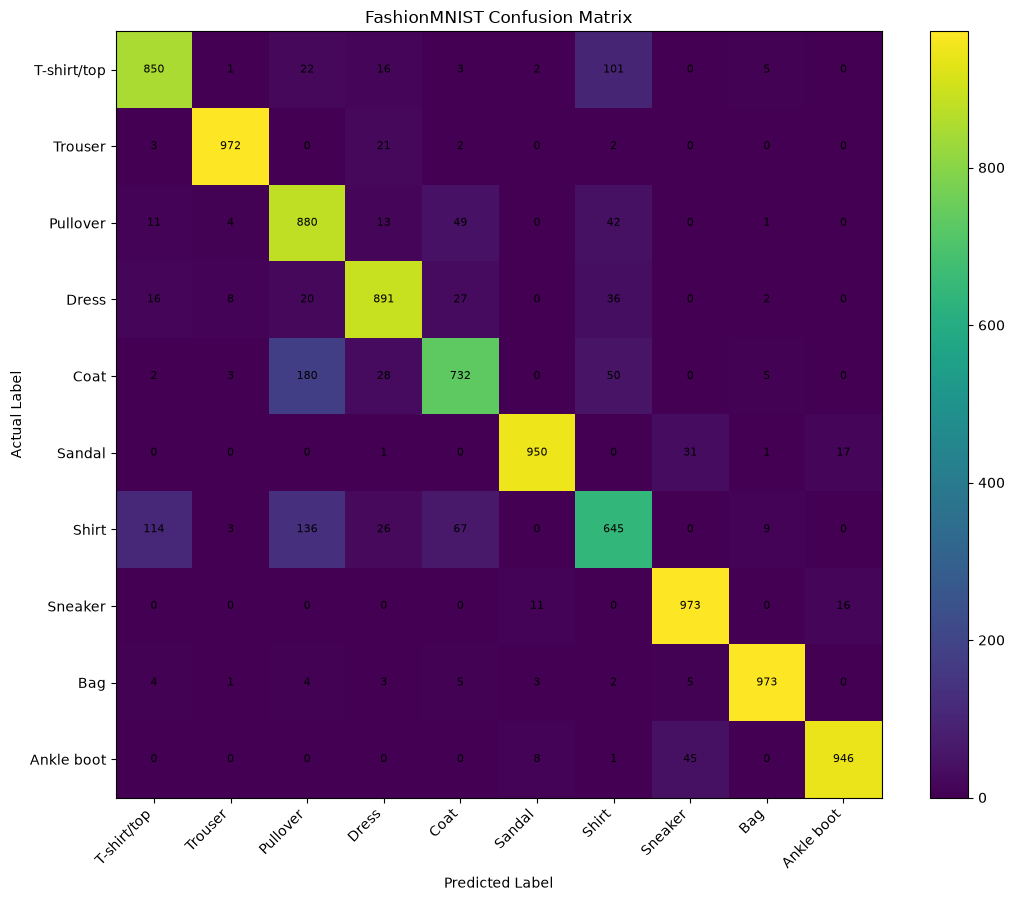

Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\confusion_matrix.png


In [14]:
def build_confusion_matrix(labels, predictions, num_classes=10):
    matrix = np.zeros((num_classes, num_classes), dtype=np.int64)
    for actual, predicted in zip(labels, predictions):
        matrix[actual, predicted] += 1
    return matrix


confusion_matrix = build_confusion_matrix(
    labels_array,
    predictions_array,
    num_classes=len(CLASS_NAMES),
)

CONFUSION_MATRIX_PATH = FIGURE_DIR / "confusion_matrix.png"

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(confusion_matrix)
ax.set_title("FashionMNIST Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)

for row in range(confusion_matrix.shape[0]):
    for column in range(confusion_matrix.shape[1]):
        ax.text(column, row, str(confusion_matrix[row, column]),
                ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=ax)
fig.tight_layout()
fig.savefig(CONFUSION_MATRIX_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", CONFUSION_MATRIX_PATH)


## 5.8 ACtual vs Predicted

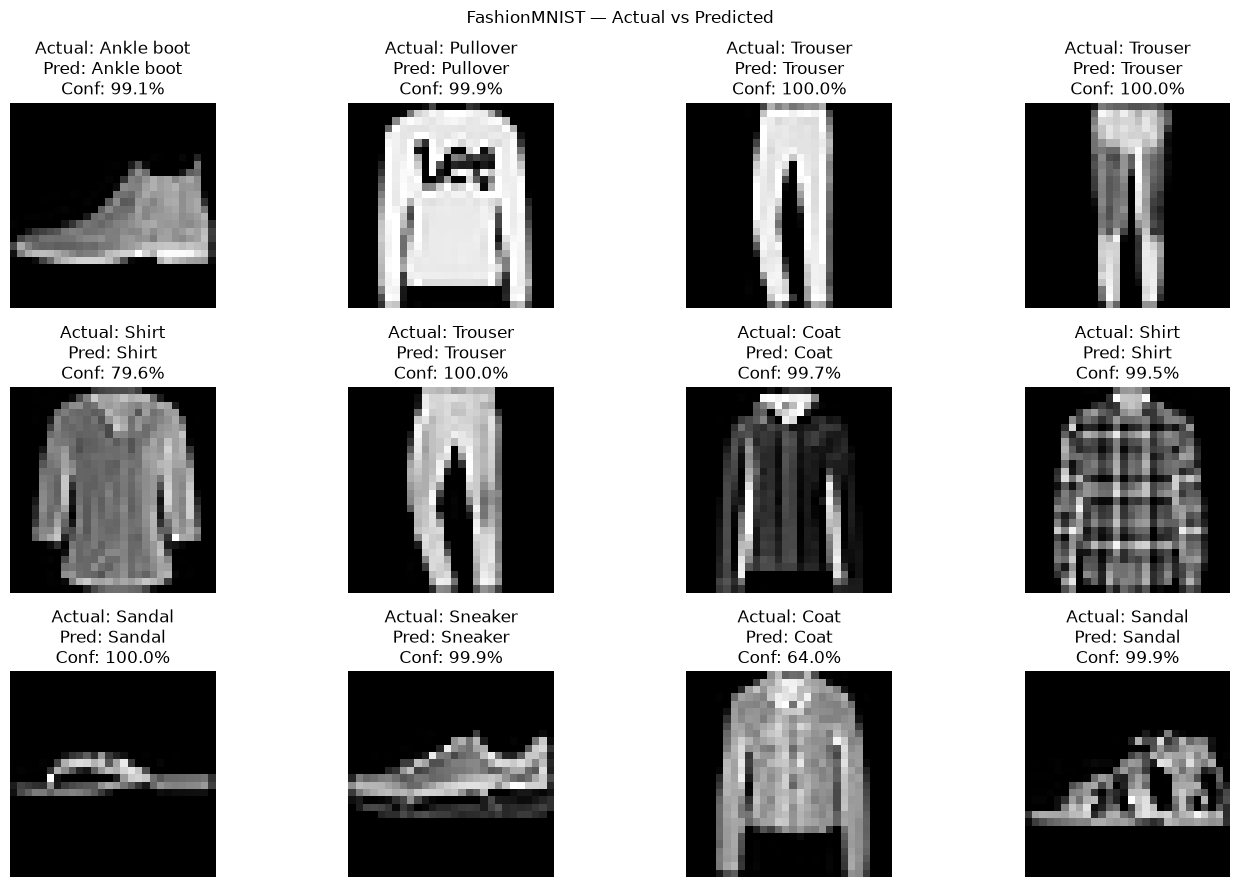

Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\predicted_vs_actual.png


In [15]:
def show_predictions(model, test_loader, class_names, device, figure_path, num_images=12):
    model.eval()
    images, labels = next(iter(test_loader))

    with torch.no_grad():
        logits = model(images.to(device))
        probabilities = torch.softmax(logits, dim=1)
        confidences, predictions = probabilities.max(dim=1)

    predictions = predictions.cpu()
    confidences = confidences.cpu()
    num_images = min(num_images, len(images))

    fig = plt.figure(figsize=(14, 9))
    for index in range(num_images):
        ax = fig.add_subplot(3, 4, index + 1)
        ax.imshow(images[index].squeeze(), cmap="gray")

        actual = class_names[labels[index].item()]
        predicted = class_names[predictions[index].item()]
        confidence = 100.0 * confidences[index].item()

        ax.set_title(
            f"Actual: {actual}\nPred: {predicted}\nConf: {confidence:.1f}%"
        )
        ax.axis("off")

    fig.suptitle("FashionMNIST — Actual vs Predicted")
    fig.tight_layout()
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()


PREDICTION_PATH = FIGURE_DIR / "predicted_vs_actual.png"
show_predictions(model, test_loader, CLASS_NAMES, device, PREDICTION_PATH)
print("Saved:", PREDICTION_PATH)


## 5.9 Các ảnh dự đoán sai

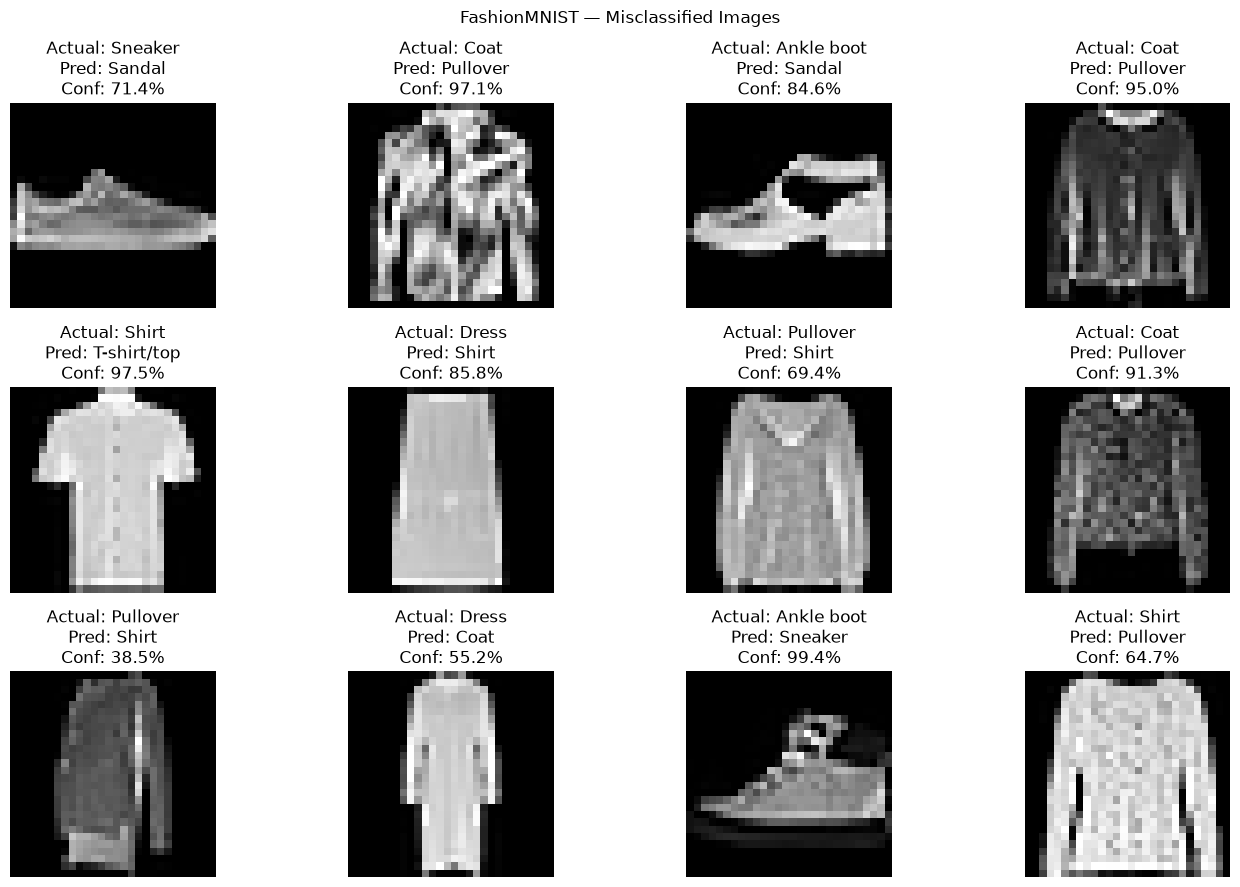

Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\misclassified_images.png


In [16]:
def show_misclassified_images(model, test_loader, class_names, device, figure_path, num_images=12):
    model.eval()
    wrong_images, wrong_labels, wrong_predictions, wrong_confidences = [], [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            logits = model(images.to(device))
            probabilities = torch.softmax(logits, dim=1)
            confidences, predictions = probabilities.max(dim=1)

            predictions = predictions.cpu()
            confidences = confidences.cpu()
            wrong_mask = predictions != labels

            for image, actual, predicted, confidence in zip(
                images[wrong_mask], labels[wrong_mask],
                predictions[wrong_mask], confidences[wrong_mask],
            ):
                wrong_images.append(image)
                wrong_labels.append(actual.item())
                wrong_predictions.append(predicted.item())
                wrong_confidences.append(confidence.item())
                if len(wrong_images) >= num_images:
                    break
            if len(wrong_images) >= num_images:
                break

    fig = plt.figure(figsize=(14, 9))
    for index, image in enumerate(wrong_images):
        ax = fig.add_subplot(3, 4, index + 1)
        ax.imshow(image.squeeze(), cmap="gray")
        actual = class_names[wrong_labels[index]]
        predicted = class_names[wrong_predictions[index]]
        confidence = 100.0 * wrong_confidences[index]
        ax.set_title(
            f"Actual: {actual}\nPred: {predicted}\nConf: {confidence:.1f}%"
        )
        ax.axis("off")

    fig.suptitle("FashionMNIST — Misclassified Images")
    fig.tight_layout()
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()


MISCLASSIFIED_PATH = FIGURE_DIR / "misclassified_images.png"
show_misclassified_images(
    model, test_loader, CLASS_NAMES, device, MISCLASSIFIED_PATH
)
print("Saved:", MISCLASSIFIED_PATH)


## 5.10 Các cặp lớp bị nhầm lẫn nhiều nhất

In [17]:
confusion_pairs = []
for actual_index in range(len(CLASS_NAMES)):
    for predicted_index in range(len(CLASS_NAMES)):
        if actual_index == predicted_index:
            continue
        confusion_pairs.append((
            int(confusion_matrix[actual_index, predicted_index]),
            CLASS_NAMES[actual_index],
            CLASS_NAMES[predicted_index],
        ))

confusion_pairs.sort(reverse=True)

print("Top 5 most common confusions")
print("-" * 60)
for rank, (count, actual_name, predicted_name) in enumerate(confusion_pairs[:5], 1):
    print(
        f"{rank}. Actual: {actual_name:<14} "
        f"→ Predicted: {predicted_name:<14} ({count} images)"
    )


Top 5 most common confusions
------------------------------------------------------------
1. Actual: Coat           → Predicted: Pullover       (180 images)
2. Actual: Shirt          → Predicted: Pullover       (136 images)
3. Actual: Shirt          → Predicted: T-shirt/top    (114 images)
4. Actual: T-shirt/top    → Predicted: Shirt          (101 images)
5. Actual: Shirt          → Predicted: Coat           (67 images)


## 5.11 Tổng kết

In [19]:
print("FINAL EVALUATION SUMMARY REPORT")
print(f"Test Loss     : {evaluation['test_loss']:.4f}")
print(f"Test Accuracy : {evaluation['test_accuracy']:.2f}%")
print(
    f"Best class    : {CLASS_NAMES[best_class_index]} "
    f"({class_accuracy[best_class_index]:.2f}%)"
)
print(
    f"Worst class   : {CLASS_NAMES[worst_class_index]} "
    f"({class_accuracy[worst_class_index]:.2f}%)"
)
print("Checkpoint    :", MODEL_PATH.name)
print("Confusion file:", CONFUSION_MATRIX_PATH.name)
print("Prediction file:", PREDICTION_PATH.name)
print("Error file    :", MISCLASSIFIED_PATH.name)


FINAL EVALUATION SUMMARY REPORT
Test Loss     : 0.3415
Test Accuracy : 88.12%
Best class    : Sneaker (97.30%)
Worst class   : Shirt (64.50%)
Checkpoint    : fashion_mnist_mlp_trained.pth
Confusion file: confusion_matrix.png
Prediction file: predicted_vs_actual.png
Error file    : misclassified_images.png
